In [68]:
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

import xarray as xr

import os 
import sys
parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

parent_dir = os.path.abspath('../..')
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

import seaborn as sns
sns.set_theme()

from scipy.optimize import minimize, basinhopping

from create_nonbootstrap_figs import createMapPanel

from maximize_ratio import *
seed = 26052026

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [69]:
config_data = "old_data"

FullSensMatrix = np.load(f"{config_data}/SensMatrix.npy")
FullCurvMatrix = np.load(f"{config_data}/CurvMatrix.npy")
FullSensMatrixSST4K = np.load(f"{config_data}/SensMatrixSST4K.npy")
FullCurvMatrixSST4K = np.load(f"{config_data}/CurvMatrixSST4K.npy")

params = np.load(f"{config_data}/PPE_params.npy")

# metric_weights = np.load("data/metric_weights.npy")


# ppe_deltas = np.load("data/diff_from_def_PPE.npy")
# ppe_deltas_sst4k = np.load("data/diff_from_def_PPE_sst4k.npy")




In [70]:
default_params = np.array([2.4,0.12,3600,-0.7e-3,2.5e-6,150e-6,7.0,1.5,-1.2,1.15,25e-6,20e6,0.018,1.35])
params_names = np.array(['clubb_c1','clubb_gamma_coef','zmconv_tau','zmconv_dmpdz','zmconv_ke','zmconv_micro_dcs','zmconv_auto_fac','zmconv_accr_fac','p3_nc_autocon_expon','p3_qc_accret_expon','p3_embryonic_rain_size','p3_mincdnc','cldfrc_dp1','nucleate_ice_subgrid']) 
low_params = np.array([1.0, 0.1, 1800, -2.0e-3, 0.5e-6, 100e-6, 3.0, 1.3, -1.79, 1.1, 15e-6, 5e6, 0.01, 1.0])
high_params = np.array([5.0, 0.5, 14400, -0.1e-3, 10e-6, 400e-6, 7.5, 2.0, -0.7, 1.3, 40e-6, 30e6, 0.1, 1.4])


def normalize_params(params):
    return (params - default_params) / np.abs(default_params)

def denormalize_params(normlzd_params):
    return normlzd_params * np.abs(default_params) + default_params
    
#continue using corrected mincdnc  but omitting suffix
normlzd_low_params = (low_params - default_params) / np.abs(default_params)
normlzd_high_params = (high_params - default_params) / np.abs(default_params)

def sanity_check_params(params):
    low_true = np.all(params >= normlzd_low_params)
    high_true = np.all(params <= normlzd_high_params)
    return low_true and high_true

bounds = list(zip(normlzd_low_params, normlzd_high_params))

In [71]:


#Get the parameters from the PPE

dataprefix = "1520260310"

def get_filenames(path, dataprefix):
    folder = Path(path)
    
    if not folder.is_dir():
        raise ValueError(f"The provided path '{path}' is not a valid directory.")
    
    pattern= f"{dataprefix}_*_Regional.nc"

    files = [str(file) for file in folder.glob(pattern) if file.is_file()]

    return files

 
files = get_filenames("/home/nobrewi2/quadtune_dev/quadtune/tuning_files/Regional_files/baseline_15D/", dataprefix)

sst4k_files = get_filenames("/home/nobrewi2/quadtune_dev/quadtune/tuning_files/Regional_files/P4K_15D/", dataprefix)

default_file = "/home/nobrewi2/quadtune_dev/quadtune/tuning_files/Regional_files/baseline_15D/1520260310_1_Regional.nc"

sst4k_default_file = "/home/nobrewi2/quadtune_dev/quadtune/tuning_files/Regional_files/P4K_15D/1520260310_P4K_1_Regional.nc"





files.sort(key=lambda x: int(x.split('_')[-2]))
sst4k_files.sort(key=lambda x: int(x.split('_')[-2]))

# params = []

# for file in files[:29]:
#     dataset = xr.open_dataset(file,engine="netcdf4")
#     param_values = dataset[params_names].to_array().values
#     params.append(param_values.flatten())

# np.save("data/PPE_params.npy", np.array(params))
global_averages_obs = [-45.30901732406915,  25.81230998182771,   2.6904643040278655, 24.39980138451228 ]
E3SM_metric_deltas = np.array([calc_metric_sum_delta_from_file(file,default_file,["SWCF","LWCF","PRECT"],global_averages_obs[:3],15) for file in files[29:]])
params_E3SM_runs = get_params_from_files(files[29:],params_names)
# print(E3SM_metric_deltas)
# print(np.load("data/S_const_with_L_e3sm_res.npy"))
# np.save("data/S_const_with_L_e3sm_res",E3SM_metric_deltas)
# E3SM_metric_deltas_sst4k = np.array([calc_metric_sum_delta_from_file(file,sst4k_default_file,["SWCF","LWCF","PRECT"],global_averages_obs[:3],15) for file in sst4k_files[29:]])
# np.save("data/S_const_with_L_e3sm_res_sst4k",E3SM_metric_deltas_sst4k)

# PPE_deltas = np.array([calc_metric_sum_delta_from_file(file,default_file,["SWCF","LWCF","PRECT","TMQ"],global_averages_obs,15) for file in files[:29]])
# np.save("data/diff_from_def_PPE",PPE_deltas)
# PPE_deltas_sst4k = np.array([calc_metric_sum_delta_from_file(file,sst4k_default_file,["SWCF","LWCF","PRECT","TMQ"],global_averages_obs,15) for file in sst4k_files[:29]])
# np.save("data/diff_from_def_PPE_sst4k",PPE_deltas_sst4k)

normlzd_params = (params - default_params) / np.abs(default_params)

 S and C where created by fitting Quadtune to Zhuns high p3_mincdnc ensemble.   
  The tuning results using Powell where:  
 tunedMetricGlobalAvgs = [-44.87313086  23.50096565]
|paramname|tuned value| percentage in range| default|
|:---|:---|:---|:---|
|clubb_c1|4.0403587| [76.01%]|       2.4000001
|clubb_gamma_coef|0.1160497| [ 4.01%]|       0.1200000
|zmconv_tau|3128.2754117| [10.54%]|    3600.0000000
|zmconv_dmpdz|-0.0005876| [74.34%]|      -0.0007000
|zmconv_ke|0.0000021| [16.65%]|       0.0000025
|zmconv_micro_dcs|0.0001692| [23.05%]|       0.0001500
|zmconv_auto_fac|6.8750566| [86.11%]|       7.0000000
|zmconv_accr_fac|1.4262214| [18.03%]|       1.5000000
|p3_nc_autocon_expon|-1.1819626| [55.78%]|      -1.2000000
|p3_qc_accret_expon|1.1707544| [35.38%]|       1.1500000
|p3_embryonic_rain_size|0.0000220| [28.03%]|       0.0000250
|p3_mincdnc|.6559999| [45.80%]| 20000000.0000000
|cldfrc_dp1|0.0162672| [ 6.96|%]       0.0180000
|nucleate_ice_subgrid|1.3237520| [80.94%]|       1.3500000
chisqdMinRatio (all metrics, non-unity metricsWeights) = 0.8093377509611663
chisqdUnweightedMinRatio (all metrics, metricsWeights=1) = 0.9070738448689439
chisqdGlobTunedMinRatio = 1.9529112741362047
chisqdUnweightedGlobTunedMinRatio = 1.8119547587839817

In [72]:
#Define all matrices

SWCF_SensMatrix = FullSensMatrix[:288,:]
SWCF_CurvMatrix = FullCurvMatrix[:288,:]
SWCF_SensMatrixSST4K = FullSensMatrixSST4K[:288,:]
SWCF_CurvMatrixSST4K = FullCurvMatrixSST4K[:288,:]

SWCF_data = [SWCF_SensMatrix,SWCF_CurvMatrix,SWCF_SensMatrixSST4K,SWCF_CurvMatrixSST4K]

LWCF_SensMatrix = FullSensMatrix[288:576,:]
LWCF_CurvMatrix = FullCurvMatrix[288:576,:]
LWCF_SensMatrixSST4K = FullSensMatrixSST4K[288:576,:]
LWCF_CurvMatrixSST4K = FullCurvMatrixSST4K[288:576,:]

LWCF_data = [LWCF_SensMatrix,LWCF_CurvMatrix,LWCF_SensMatrixSST4K,LWCF_CurvMatrixSST4K]

PRECT_SensMatrix = FullSensMatrix[576:864,:]
PRECT_CurvMatrix = FullCurvMatrix[576:864,:]
PRECT_SensMatrixSST4K = FullSensMatrixSST4K[576:864,:]
PRECT_CurvMatrixSST4K = FullCurvMatrixSST4K[576:864,:] 

PRECT_data = [PRECT_SensMatrix,PRECT_CurvMatrix,PRECT_SensMatrixSST4K,PRECT_CurvMatrixSST4K]

TMQ_SensMatrix = FullSensMatrix[864:,:]
TMQ_CurvMatrix = FullCurvMatrix[864:,:]
TMQ_SensMatrixSST4K = FullSensMatrixSST4K[864:,:]
TMQ_CurvMatrixSST4K = FullCurvMatrixSST4K[864:,:] 

TMQ_data = [TMQ_SensMatrix,TMQ_CurvMatrix,TMQ_SensMatrixSST4K,TMQ_CurvMatrixSST4K]

LWCF_PRECT_SensMatrix = np.vstack((LWCF_SensMatrix, PRECT_SensMatrix))
LWCF_PRECT_CurvMatrix = np.vstack((LWCF_CurvMatrix, PRECT_CurvMatrix))
LWCF_PRECT_SensMatrixSST4K = np.vstack((LWCF_SensMatrixSST4K, PRECT_SensMatrixSST4K))
LWCF_PRECT_CurvMatrixSST4K = np.vstack((LWCF_CurvMatrixSST4K, PRECT_CurvMatrixSST4K))

LWCF_PRECT_data = [LWCF_PRECT_SensMatrix, LWCF_PRECT_CurvMatrix, LWCF_PRECT_SensMatrixSST4K,LWCF_PRECT_CurvMatrixSST4K]


all_data = {
    "SWCF" : SWCF_data,
    "LWCF" : LWCF_data,
    "PRECT": PRECT_data,
    "TMQ"  : TMQ_data,
    "LWCF_PRECT" : LWCF_PRECT_data
}



available_fields = ["SWCF","LWCF","PRECT"]#,"TMQ"]
global_averages_obs = [-45.30901732406915,  25.81230998182771,2.6904643040278655, 24.39980138451228 ]


In [73]:
#Configure
combined_future = False
base_var_name = "SWCF"


constr_var_name = "LWCF"

constr_var_names = ["LWCF"]

base_data = all_data[base_var_name]
constr_data = all_data[constr_var_name]




# deltas = np.load("data/S_const_with_L_e3sm_res.npy")
# deltas_sst4k = np.load("data/S_const_with_L_e3sm_res_sst4k.npy")

index = [available_fields.index(item) for item in [base_var_name,*constr_var_names]]

# ppe_e3sm_res = np.array([ppe_deltas,ppe_deltas_sst4k])[:,:,index]
ppe_e3sm_res = None


In [74]:
if combined_future:
    future_name = base_var_name+"_"+constr_var_name
else:
    future_name = base_var_name

In [86]:
optimizer_results = optimize_all(base_var_name,*base_data,constr_var_name, *constr_data,bounds, combined_future = combined_future,eps=1e-4, use_grad=False, reg_gamma= 0.5)
# optimizer_results = maximize_ratio(base_var_name,*base_data,constr_var_name, *constr_data,bounds, combined_future = combined_future,eps=1e-4, use_grad=False, reg_gamma= 0.5)

Maximizing SWCF future over SWCF present-day 


/home/nobrewi2/.pyenv/versions/env_quadtune/lib/python3.12/site-packages/scipy/optimize/_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
/home/nobrewi2/.pyenv/versions/env_quadtune/lib/python3.12/site-packages/scipy/optimize/_slsqp_py.py:439: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)


Maximizing SWCF future over SWCF and LWCF present-day 
Maximizing present-day LWCF over present-day SWCF
Minimizing present-day LWCF over present-day SWCF


In [87]:
optimizer_results

{'res_max_F_S': (array([ 0.45347169,  0.18032454, -0.14317161, -0.19865646, -0.13202736,
         -0.1085992 , -0.03073346,  0.1615231 ,  0.04481603,  0.10582898,
          0.01923234,  0.01260178, -0.26102988,  0.03703704]),
  np.float64(2.9089196208803014)),
 'res_max_F_SL': (array([ 0.48660885,  0.05101299, -0.12980869, -0.14387957, -0.13662242,
          0.07526475,  0.01349733,  0.19489548, -0.1094352 ,  0.10876171,
          0.12553634,  0.00363221, -0.0653756 ,  0.00756798]),
  np.float64(2.037439660517078)),
 'res_max_L_S': (array([ 0.07733819, -0.01925729,  0.08488287, -0.27852297,  0.04995437,
         -0.12347229, -0.00577894, -0.00721729, -0.08289812,  0.01504674,
          0.10577948,  0.06319137,  0.17609028, -0.23940853]),
  np.float64(11.994242836086821)),
 'res_min_L_S': (array([-0.07941597, -0.00222458, -0.05231787, -0.0214306 , -0.01207298,
          0.03731218, -0.00985573,  0.01795139, -0.16924202,  0.07203567,
          0.14038769,  0.0834122 , -0.04829298, -0.012

In [85]:
old_results

{'res_max_F_S': (array([ 0.48075172,  0.18012216, -0.08464323, -0.08054767, -0.41562983,
         -0.15988837, -0.44805365,  0.09738572, -0.13765193,  0.04991815,
         -0.05089934,  0.12175048, -0.44444444,  0.02879259]),
  np.float64(3.5977138503160986)),
 'res_max_F_SL': (array([ 0.70065256,  0.06385554, -0.1419089 , -0.15849032, -0.18031668,
          0.11255717,  0.00309188,  0.19457046, -0.16702471,  0.10204927,
          0.16620695, -0.01544295, -0.05319078,  0.01004445]),
  np.float64(2.2594318917716225)),
 'res_max_L_S': (array([ 0.10129861, -0.01248955,  0.08123584, -0.51882078,  0.03028162,
         -0.15102843, -0.00272189, -0.00539001, -0.1298359 ,  0.00958597,
          0.206155  ,  0.07607832,  0.27489614, -0.24038994]),
  np.float64(14.39696726596037)),
 'res_min_L_S': (array([-0.14873689,  0.00462876, -0.05163992, -0.03276505,  0.00895861,
          0.04925894, -0.00807247,  0.03659196, -0.2021794 ,  0.06790783,
          0.30378088,  0.10522922, -0.04195928, -0.014

In [64]:
# get correct E3SM runs
params = np.array([val [0] for val in list(optimizer_results.values())])[:-1]

denormalized_params = [denormalize_params(paramset) for paramset in params]

non_PPE_sst4k_files = np.array(sst4k_files[29:])
non_PPE_files = np.array(files[29:])

e3sm_res = get_correct_model_runs_delta(denormalized_params,params_E3SM_runs,non_PPE_files,non_PPE_sst4k_files, default_file, sst4k_default_file,np.array(available_fields)[index], np.array(global_averages_obs)[index])


In [65]:
PPE_deltas = e3sm_res[0]
PPE_deltas_sst4k = e3sm_res[1]

PPE_F_B_E3SM_ratios = PPE_deltas_sst4k[:,0]/PPE_deltas[:,0]
PPE_F_BC_E3SM_ratios = PPE_deltas_sst4k[:,0]/np.sum(PPE_deltas,axis=1)

print(list(optimizer_results.keys()))
print(f" Future values: {PPE_deltas_sst4k[:,0]}")
print(f" Simple denominator: {PPE_deltas[:,0]}")
print(f" combined denominator: {np.sum(PPE_deltas,axis=1)}")

print(f"Ratios F_S {PPE_deltas_sst4k[:,0]/PPE_deltas[:,0]}")
print(f"Ratios F_SL {PPE_deltas_sst4k[:,0]/np.sum(PPE_deltas,axis=1)}")

['res_max_F_S', 'res_max_F_SL', 'res_max_L_S', 'res_min_L_S']
 Future values: [2.20450783 3.55963898 1.60091424]
 Simple denominator: [1.17392063 1.81008935 1.95885801]
 combined denominator: [ 1.85587204  2.33910716 12.51435041]
Ratios F_S [1.87790194 1.96655429 0.81726916]
Ratios F_SL [1.18785551 1.52179389 0.12792628]


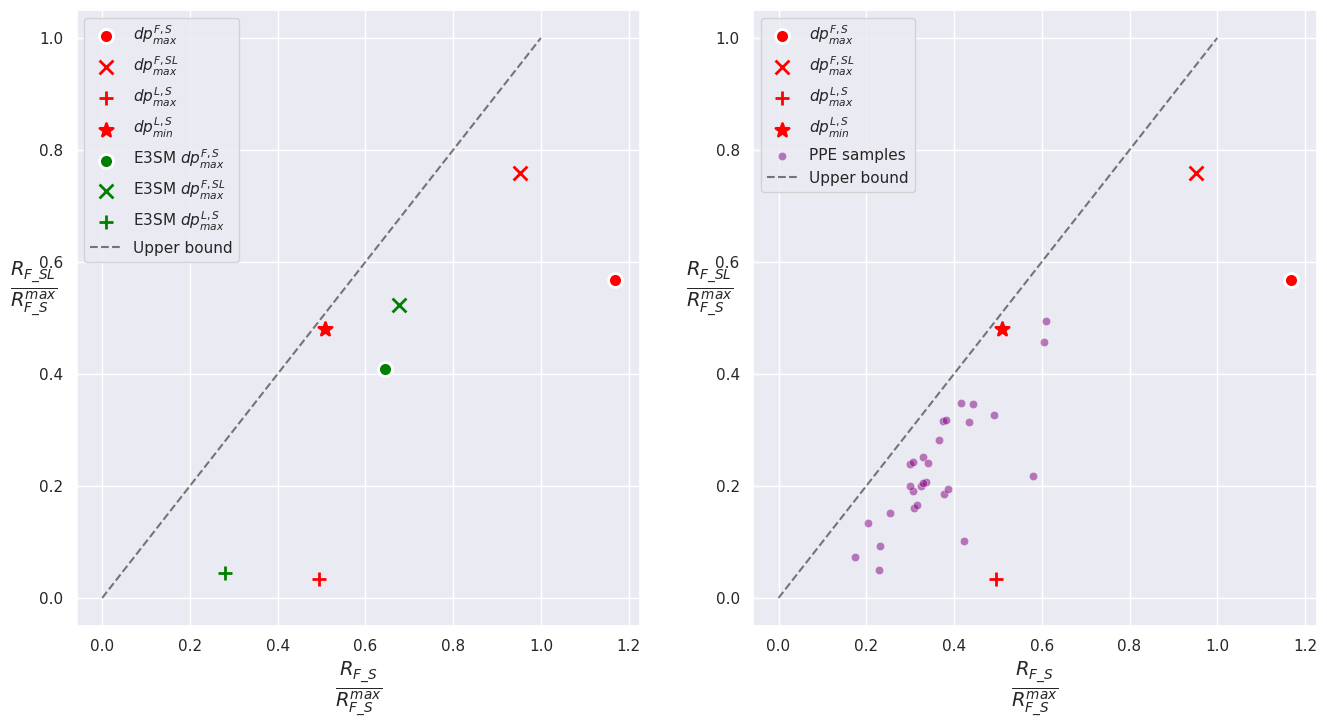

In [93]:
fig, ax = plt.subplots(1,2, figsize=((16,8)))

make_scatterplot(optimizer_results,base_var_name,*base_data,constr_var_name,
                  *constr_data,
                    combined_future= combined_future,e3sm_PPE_results= ppe_e3sm_res , e3sm_optimized_results=e3sm_res, ax = ax[0])

make_scatterplot(optimizer_results,base_var_name,*base_data,constr_var_name,
                  *constr_data,
                    combined_future= combined_future, additional_params = normlzd_params, ax = ax[1])
# plt.savefig(f"plots/Scatter_{future_name}_future_{base_var_name}_constr_by_{constr_var_name}")
plt.show()

In [94]:
print(params_names)
print(denormalize_params(optimizer_results["res_max_F_S"][0]))


['clubb_c1' 'clubb_gamma_coef' 'zmconv_tau' 'zmconv_dmpdz' 'zmconv_ke'
 'zmconv_micro_dcs' 'zmconv_auto_fac' 'zmconv_accr_fac'
 'p3_nc_autocon_expon' 'p3_qc_accret_expon' 'p3_embryonic_rain_size'
 'p3_mincdnc' 'cldfrc_dp1' 'nucleate_ice_subgrid']
[ 3.48833206e+00  1.41638945e-01  3.08458221e+03 -8.39059524e-04
  2.16993161e-06  1.33710120e-04  6.78486577e+00  1.74228465e+00
 -1.14622076e+00  1.27170333e+00  2.54808085e-05  2.02520356e+07
  1.33014621e-02  1.40000000e+00]


In [49]:
print(denormalize_params(old_data["res_max_F_S"][0]))

[ 2.98674649e+00  1.95673052e-01  3.32794372e+03 -7.96236776e-04
  3.01411119e-06  1.23598056e-04  5.24784301e+00  1.71645683e+00
 -1.10018234e+00  1.20811877e+00  2.48501630e-05  1.95406904e+07
  1.31358781e-02  1.37545834e+00]


In [91]:
data = evaluate_model(optimizer_results["res_max_F_S"][0], SWCF_SensMatrix, SWCF_CurvMatrix)
default_data = get_data_from_file(default_file, ["SWCF"])
denorm_data = denormalize_metrics_data(data, default_data, [global_averages_obs[0]])


print(optimizer_results["res_max_F_S"][1])
createMapPanel(data,600,"",15)
# fig.write_image("regularized_res_max_F_S_sst4k.png")

2.9089196208803014


In [51]:
data = evaluate_model(old_data["res_max_F_S"][0], SWCF_SensMatrix, SWCF_CurvMatrix)
default_data = get_data_from_file(default_file, ["SWCF"])
denorm_data = denormalize_metrics_data(data, default_data, [global_averages_obs[0]])


print(old_data["res_max_F_S"][1])
createMapPanel(data,600,"",15)

3.379456879067829


In [44]:

old_data

{'res_max_F_S': (array([ 0.2444777 ,  0.63060877, -0.07557119, -0.13748111,  0.20564448,
         -0.17601296, -0.25030814,  0.14430456,  0.08318138,  0.05053806,
         -0.00599348, -0.02296548, -0.27022899,  0.01885803]),
  np.float64(3.379456879067829)),
 'res_max_F_SP': (array([ 4.57388053e-01,  1.59347277e-01,  5.14583742e-02, -2.46724373e-01,
         -1.07212890e-01, -4.36685054e-04, -2.38575132e-02,  9.76914328e-02,
         -1.89360954e-01,  1.00163128e-01,  9.76299780e-02, -1.03997051e-02,
         -4.50810910e-02,  1.26138606e-02]),
  np.float64(1.637875265691725)),
 'res_max_P_S': (array([ 0.06277968,  0.31911624, -0.5       , -0.53105262,  2.90024445,
         -0.12370044,  0.07142857, -0.13333333, -0.24667184, -0.0130724 ,
          0.01893509, -0.17384922,  0.49093001, -0.05308941]),
  np.float64(6.752032224522369)),
 'res_min_P_S': (array([-0.14075818,  0.28681811,  0.33271692, -0.23324473,  0.21467399,
          0.21921261, -0.0410094 ,  0.02855596, -0.24460142,  0.0

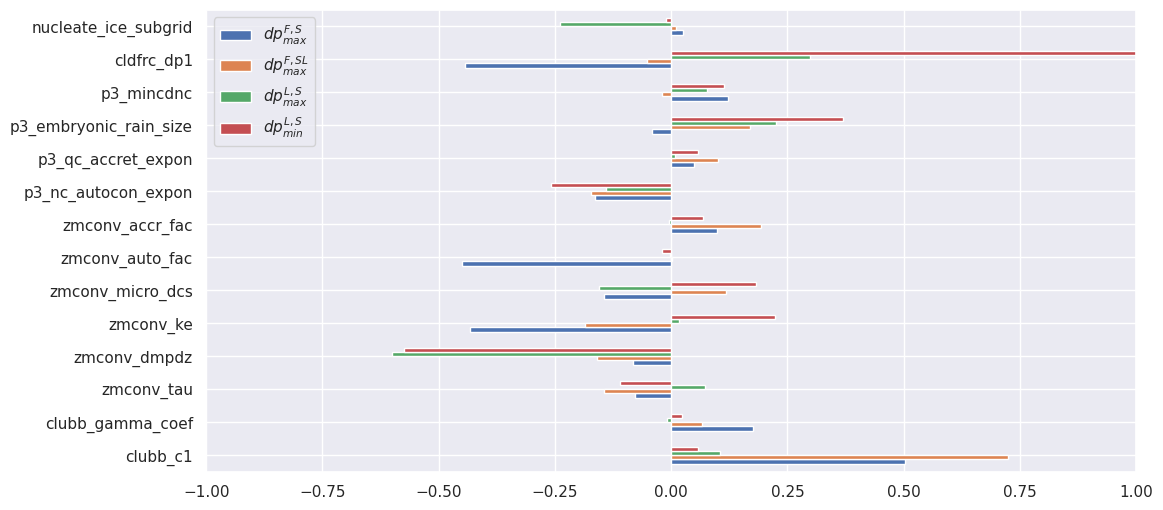

In [ ]:
create_parameter_bar_chart(optimizer_results,params_names,base_var_name,constr_var_name)
# plt.savefig(f"plots/Params_bar_{future_name}_future_{base_var_name}_constr_by_{constr_var_name}",bbox_inches='tight', dpi=300)
plt.show()


In [ ]:
kappa = R_max_L_S / R_min_L_S
k_on_n = 2/14
f_ortho_max = (1+ k_on_n  * (kappa-1))  / (kappa**k_on_n)

print(np.linalg.det(get_H_at_dp(LWCF_SensMatrix,LWCF_CurvMatrix,dp_max_L_S)) ** (1/14))
print(np.linalg.det(get_H_at_dp(LWCF_SensMatrix,LWCF_CurvMatrix,dp_max_F_S)) ** (1/14))
print(np.linalg.det(get_H_at_dp(LWCF_SensMatrix,LWCF_CurvMatrix,dp_max_F_SL)) ** (1/14))
print("---------------")
print(np.linalg.det(get_H_at_dp(SWCF_SensMatrix,SWCF_CurvMatrix,dp_max_L_S)) ** (1/14))
print(np.linalg.det(get_H_at_dp(SWCF_SensMatrix,SWCF_CurvMatrix,dp_max_F_S)) ** (1/14))
print(np.linalg.det(get_H_at_dp(SWCF_SensMatrix,SWCF_CurvMatrix,dp_max_F_SL)) ** (1/14))
print("---------------")


H_L = get_H_at_dp(LWCF_SensMatrix,LWCF_CurvMatrix,dp_max_L_S)
H_base_inv  = np.linalg.inv(get_H_at_dp(SWCF_SensMatrix,SWCF_CurvMatrix,dp_max_L_S))

print(np.trace(H_base_inv @ H_L))

H_L = get_H_at_dp(LWCF_SensMatrix,LWCF_CurvMatrix,dp_max_F_S)
H_base_inv  = np.linalg.inv(get_H_at_dp(SWCF_SensMatrix,SWCF_CurvMatrix,dp_max_F_S))

print(np.trace(H_base_inv @ H_L))


H_L = get_H_at_dp(LWCF_SensMatrix,LWCF_CurvMatrix,dp_max_F_SL)
H_base_inv  = np.linalg.inv(get_H_at_dp(SWCF_SensMatrix,SWCF_CurvMatrix,dp_max_F_SL))


print(np.trace(H_base_inv @ H_L))




NameError: name 'R_max_L_S' is not defined

In [ ]:
# dp_max_Q_S = res["res_max_T_S"][0]


# num_dims = len(params_names)
# H_S = get_H_at_dp(SWCF_SensMatrix, SWCF_CurvMatrix, dp_max_Q_S)
# H_S_inv= np.linalg.inv(H_S)
# H_Q = get_H_at_dp(TMQ_SensMatrix, TMQ_CurvMatrix, dp_max_Q_S)

dp_max_L_S = optimizer_results["res_max_L_S"][0]

num_dims = len(params_names)
H_S = get_H_at_dp(SWCF_SensMatrix, SWCF_CurvMatrix, dp_max_L_S)
H_S_inv= np.linalg.inv(H_S)
H_L = get_H_at_dp(LWCF_SensMatrix, LWCF_CurvMatrix, dp_max_L_S)


print(calc_D_opt_metrics(dp_max_L_S, SWCF_SensMatrix, SWCF_CurvMatrix, LWCF_SensMatrix, LWCF_CurvMatrix))
print(calc_A_opt_metrics(dp_max_L_S, SWCF_SensMatrix, SWCF_CurvMatrix, LWCF_SensMatrix, LWCF_CurvMatrix))

# dp_max_Q_S = res["res_max_P_S"][0]


# dp_max_L_S = res["res_max_L_S"][0]
# num_dims = len(params_names)
# H_S = get_H_at_dp(SWCF_SensMatrix, SWCF_CurvMatrix, dp_max_L_S)
# H_S_inv= np.linalg.inv(H_S)
# H_L = get_H_at_dp(LWCF_SensMatrix, LWCF_CurvMatrix, dp_max_L_S)



    

def calculate_optimalities(H_base, H_constr):
    H_base_inv = np.linalg.inv(H_base)

    F_vol = np.linalg.det(H_base_inv@H_constr)**(1/num_dims)
    print(f"F_vol = {F_vol}")

    A_opt = np.trace(H_base_inv@H_constr)
    # print(f"A_opt = {A_opt}")

    A_opt_on_n = A_opt/num_dims

    print(f"A_opt_on_n = {A_opt_on_n}")

    F_ortho_a_opt = A_opt_on_n / (F_vol)

    print(f"F_ortho_a_opt = {F_ortho_a_opt}")

    D_optimality = np.linalg.det(np.eye(num_dims)+H_base_inv@H_constr)

    D_optimality_1_on_n = D_optimality**(1/num_dims)

    F_ortho_d_opt = D_optimality_1_on_n / (1 + F_vol)

    # print(f"D_opt = {D_optimality}")
    print(f"D_opt_1_on_n = {D_optimality_1_on_n}")
    print(f"F_ortho_d_opt = {F_ortho_d_opt}")

calculate_optimalities(H_S,H_L)
# # calculate_optimalities(H_S,H_Q)
# calculate_optimalities(H_S,H_L)
# print('xxxxxxxxxxx')



(np.float64(2.0742425961111497), np.float64(1.113438015040031))
(np.float64(1.341483132503069), np.float64(1.5545911683713538))
F_vol = 0.8629169905219874
A_opt_on_n = 1.341483132503069
F_ortho_a_opt = 1.5545911683713538
D_opt_1_on_n = 2.07424259611115
F_ortho_d_opt = 1.1134380150400311


In [ ]:
PRECT (S-future,max P over S)
F_scale = 1.971942580810886
A_opt_on_n = 2.6895673778667346
F_ortho_a_opt = 1.363917694175838
D_opt_1_on_n = 3.296623604931551
F_ortho_d_opt = 1.1092487540698301

(min P over S)
F_scale = 2.0758679049066613
A_opt_on_n = 2.7744392066060235
F_ortho_a_opt = 1.3365201128878057
D_opt_1_on_n = 3.3847507022288523
F_ortho_d_opt = 1.1004213467130555

In [ ]:
TMQ (S-future, T over S)
F_scale = 0.13027600423860367
A_opt_on_n = 0.19620733138397317
F_ortho_a_opt = 1.5060895713735176
D_opt_1_on_n = 1.1856721009019267
F_ortho_d_opt = 1.049011123350035

In [ ]:
LWCF(S-future, L over S)

F_scale = 0.8629169905219874
A-opt_on_n = 1.341483132503069
F_ortho_a_opt = 1.5545911683713538
D_opt_1_on_n = 2.07424259611115
F_ortho_d_opt = 1.1134380150400311

In [ ]:
A_opt = 2.7469026393756244
F_scale = 0.13027600423860367
D_opt = 10.851865773178186
D_opt_1_on_n = 1.1856721009019267
F_ortho_d_opt = 1.049011123350035

In [ ]:



H_S = get_H_at_dp(SWCF_SensMatrix, SWCF_CurvMatrix, dp_max_F_SL)
print(np.linalg.cond(H_S))
lambda_L_S = R_max_L_S**2

lambda_F_S = R_max_F_S**2

lambda_F_SL = R_max_F_SL**2

c= lambda_F_S/lambda_F_SL * (dp_max_F_S.T@H_S@dp_max_F_SL)/(dp_max_F_S.T@H_S@dp_max_F_S)
c=1
print(dp_max_F_S.T@H_S@dp_max_F_S)

coeff = lambda_L_S/(1+lambda_L_S)
ratio = (dp_max_L_S.T@H_S@dp_max_F_S)/(dp_max_L_S.T@H_S@dp_max_L_S)
u_tilde = c * (dp_max_F_S- coeff*ratio*dp_max_L_S)
print(dp_max_L_S.T@H_S@dp_max_L_S)

1376.1160072370421
33.76524076298035
36.05709546248569


In [ ]:
(dp_max_L_S.T@H_S@dp_max_F_S)/np.sqrt(dp_max_L_S.T@H_S@dp_max_L_S * dp_max_F_S.T@H_S@dp_max_F_S)

np.float64(0.999565704973772)

In [ ]:
a = np.diag(get_H_at_dp(SWCF_SensMatrix, SWCF_CurvMatrix, dp_max_F_SL))
b = np.diag(get_H_at_dp(LWCF_SensMatrix, LWCF_CurvMatrix, dp_max_F_SL))
print(params_names)
print(a)
print(b)

a/b

['clubb_c1' 'clubb_gamma_coef' 'zmconv_tau' 'zmconv_dmpdz' 'zmconv_ke'
 'zmconv_micro_dcs' 'zmconv_auto_fac' 'zmconv_accr_fac'
 'p3_nc_autocon_expon' 'p3_qc_accret_expon' 'p3_embryonic_rain_size'
 'p3_mincdnc' 'cldfrc_dp1' 'nucleate_ice_subgrid']
[  5.63296032  26.80813558   2.4800228    2.11925668   2.34082002
   6.77754942  12.8478506    4.25140227   8.22974499 826.14262273
   9.14007252   3.62120163   6.18401897 515.22275244]
[  0.92503956  14.08071936   2.58906022   6.96511993   1.56099697
   6.66190277   9.1780586    5.62634152   1.58602479  88.11921017
   2.68550084   2.16685771   3.11228175 881.59076982]


array([6.08942639, 1.90388963, 0.95788533, 0.30426708, 1.4995673 ,
       1.0173594 , 1.39984404, 0.75562464, 5.18891323, 9.37528402,
       3.40348898, 1.67117648, 1.98697273, 0.58442394])

In [ ]:
dp_max_L_S

array([ 0.10557458, -0.00923334,  0.07189636, -0.60123082,  0.01754597,
       -0.15476827, -0.00175472, -0.00401146, -0.14072021,  0.00879333,
        0.22495496,  0.07691369,  0.29928229, -0.24018655])

In [ ]:
np.dot(dp_max_F_S,dp_max_F_SL)

np.float64(-0.16256321559616338)